# GULPS Timing Benchmarks

## Experiment 1 — LP Enumeration Cost vs Gate Set Size

For each progressive ISA family (iswap, cx, mixed), the **strongest** gate pins the sentence depth while adding weaker gates increases the LP branching factor. The x-axis is `|gate_set|` and the y-axis is median LP time across random 2Q unitaries.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

import scienceplots

from qiskit.quantum_info import random_unitary

from gulps import GulpsDecomposer, GateInvariants, logger
from gulps.core.isa import DiscreteISA
from gulps.config import GulpsConfig
from gulps.isa_library.benchmark_isas import get_isa_scaling, get_depth_scaling

logger.setLevel("WARNING")

In [2]:
N_SAMPLES = 100
SEED_OFFSET = 0

isa_configs = get_isa_scaling()
print(f"Loaded {len(isa_configs)} ISA-scaling configs")

results = []
for name, gate_set in isa_configs:
    gates, costs, labels = zip(*gate_set)
    isa = DiscreteISA(gate_set=gates, costs=costs, names=labels)
    decomposer = GulpsDecomposer(isa=isa, config_options=GulpsConfig(max_depth=16))

    lp_times = []
    for idx in trange(N_SAMPLES, desc=name, leave=False):
        u = random_unitary(4, seed=SEED_OFFSET + idx)
        target_inv = GateInvariants.from_unitary(u, enforce_alcove=True)
        t0 = time.perf_counter()
        decomposer._best_decomposition(target_inv)
        lp_times.append(time.perf_counter() - t0)

    results.append(
        {
            "name": name,
            "n_gates": len(gate_set),
            "lp_times": np.array(lp_times),
            "median_lp_time": np.median(lp_times),
            "std_lp_time": np.std(lp_times),
        }
    )
    print(f"  {name:20s}  |G|={len(gate_set):2d}  median={np.median(lp_times):.4f}s")

Loaded 18 ISA-scaling configs


  iswap_prog_1g         |G|= 1  median=0.0001s


  iswap_prog_2g         |G|= 2  median=0.0001s


  iswap_prog_3g         |G|= 3  median=0.0004s


  iswap_prog_4g         |G|= 4  median=0.0011s


...

  mixed_prog_2g         |G|= 2  median=0.0001s


  mixed_prog_4g         |G|= 4  median=0.0002s


  mixed_prog_6g         |G|= 6  median=0.0010s


  mixed_prog_8g         |G|= 8  median=0.0054s


  mixed_prog_10g        |G|=10  median=0.0212s


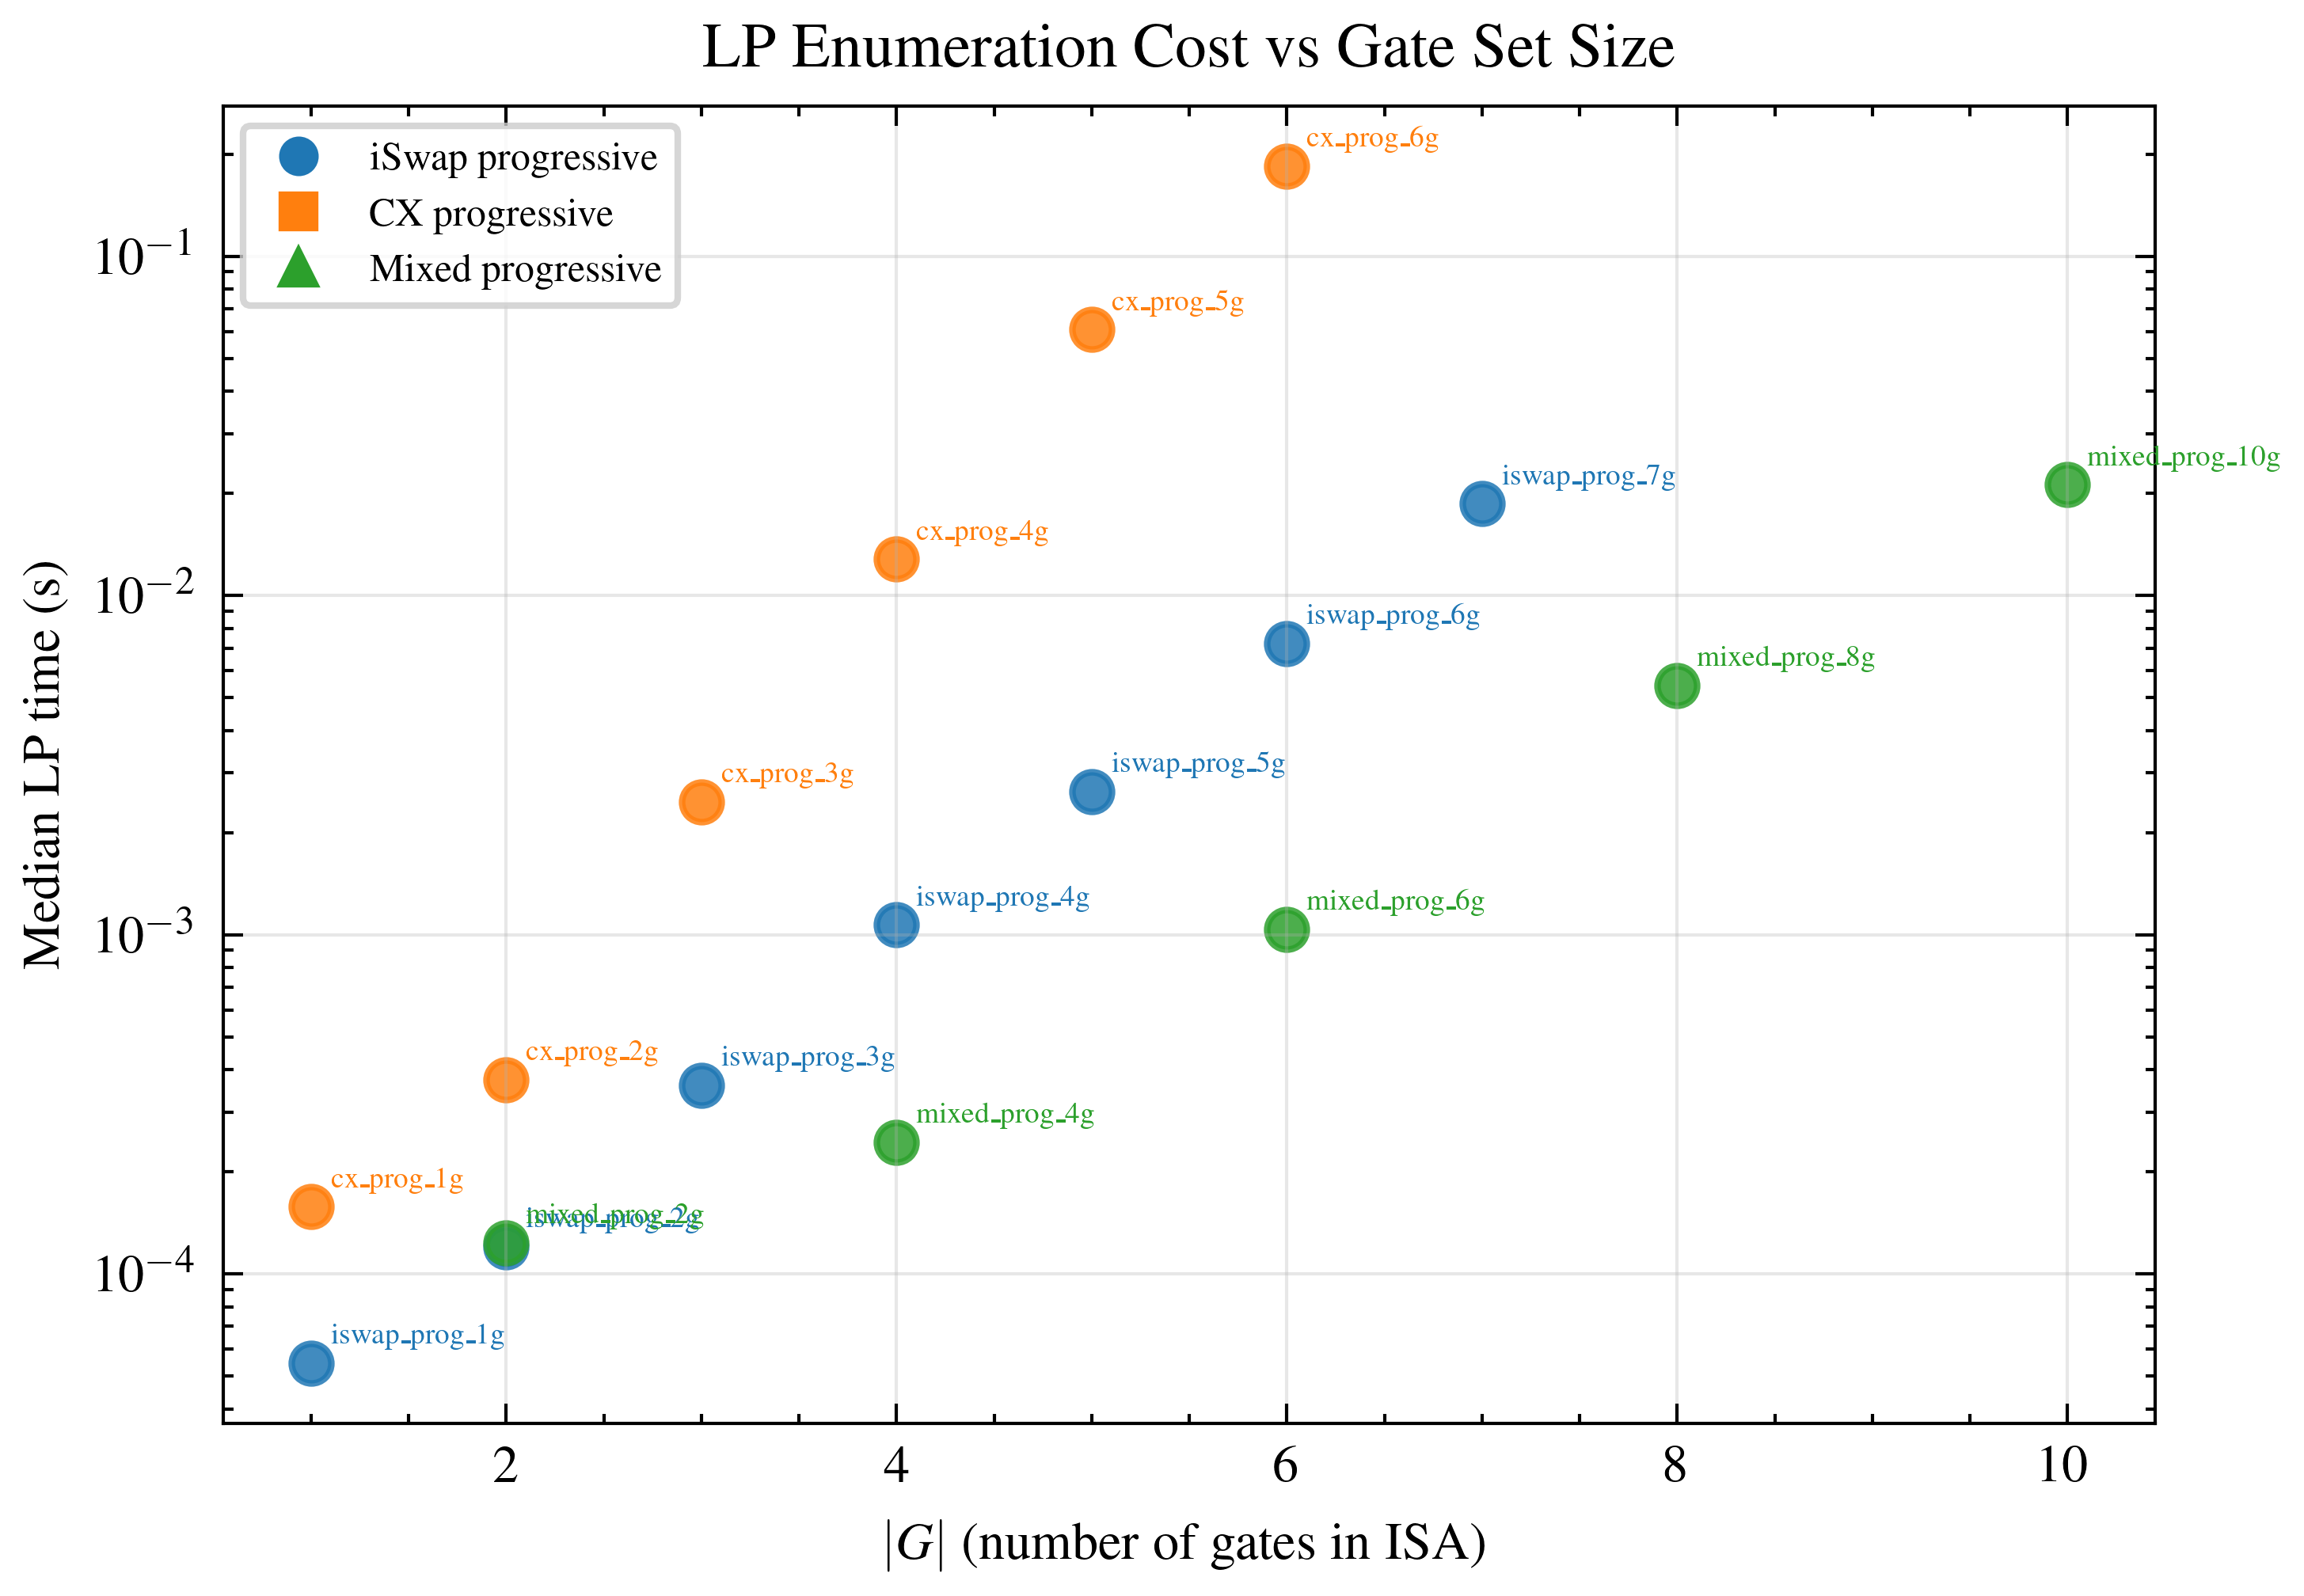

In [4]:
# --- Plot: LP time vs |gate_set|, colored by family ---
families = {
    "iswap_prog": {"color": "tab:blue", "marker": "o", "label": "iSwap progressive"},
    "cx_prog": {"color": "tab:orange", "marker": "s", "label": "CX progressive"},
    "mixed_prog": {"color": "tab:green", "marker": "^", "label": "Mixed progressive"},
}


def family_of(name):
    for key in families:
        if name.startswith(key):
            return key
    return None


import lovelyplots
import scienceplots

with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(5, 3.5))

    for r in results:
        fam = family_of(r["name"])
        sty = families[fam]
        ax.scatter(
            r["n_gates"],
            r["median_lp_time"],
            # yerr=r["std_lp_time"],
            # fmt=sty["marker"],
            color=sty["color"],
            # markersize=5,
            # capsize=3,
            # elinewidth=0.8,
            alpha=0.85,
        )
        ax.annotate(
            r["name"],
            (r["n_gates"], r["median_lp_time"]),
            fontsize=4.5,
            ha="left",
            va="bottom",
            xytext=(3, 2),
            textcoords="offset points",
            color=sty["color"],
        )

    # legend (one entry per family)
    for key, sty in families.items():
        ax.plot(
            [], [], sty["marker"], color=sty["color"], label=sty["label"], markersize=5
        )

    ax.set_xlabel(r"$|G|$ (number of gates in ISA)")
    ax.set_ylabel("Median LP time (s)")
    ax.set_title("LP Enumeration Cost vs Gate Set Size")
    ax.set_yscale("log")
    ax.legend(fontsize=6, frameon=True, loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Experiment 2 — Numeric Segment Time vs Sentence Length

Single-gate ISAs with shrinking fractional powers (1/2 → 1/8). Weaker gates require longer sentences, so the dominant variable is sentence depth. We run the **full** decomposition (`decomposer(u)`) and measure the `segments` timing — the JAX numerical solver that fits single-qubit corrections at each segment.

In [5]:
# JIT warmup — run one decomposition so JAX compiles the segment solver
_warmup_isa = DiscreteISA(
    gate_set=[get_depth_scaling()[0][1][0][0]],
    costs=[get_depth_scaling()[0][1][0][1]],
    names=[get_depth_scaling()[0][1][0][2]],
)
_warmup_dec = GulpsDecomposer(isa=_warmup_isa, config_options=GulpsConfig(max_depth=16))
_ = _warmup_dec(random_unitary(4, seed=999))
print("JIT warmup done")

JIT warmup done


In [6]:
N_SAMPLES_2 = 100
SEED_OFFSET_2 = 0

depth_configs = get_depth_scaling()
print(f"Loaded {len(depth_configs)} depth-scaling configs")

depth_results = []
for name, gate_set in depth_configs:
    gates, costs, labels = zip(*gate_set)
    isa = DiscreteISA(gate_set=gates, costs=costs, names=labels)
    decomposer = GulpsDecomposer(isa=isa, config_options=GulpsConfig(max_depth=16))

    seg_times = []
    depths = []
    failures = 0

    for idx in trange(N_SAMPLES_2, desc=name, leave=False):
        u = random_unitary(4, seed=SEED_OFFSET_2 + idx)
        try:
            circ = decomposer(u)
            seg_times.append(decomposer.last_timing["segments"])
            n_2q = sum(1 for op in circ.data if op.operation.num_qubits == 2)
            depths.append(n_2q)
        except Exception:
            failures += 1

    n_ok = len(seg_times)
    depth_results.append(
        {
            "name": name,
            "seg_times": np.array(seg_times),
            "depths": np.array(depths),
            "median_seg_time": np.median(seg_times) if n_ok else np.nan,
            "std_seg_time": np.std(seg_times) if n_ok else np.nan,
            "median_depth": np.median(depths) if n_ok else np.nan,
            "failures": failures,
        }
    )
    r = depth_results[-1]
    print(
        f"  {name:12s}  depth={r['median_depth']:.0f}  seg={r['median_seg_time']:.4f}s  fail={failures}"
    )

Loaded 14 depth-scaling configs


  iswap^1/2     depth=2  seg=0.0008s  fail=0


  iswap^1/3     depth=3  seg=0.0015s  fail=0


  iswap^1/4     depth=4  seg=0.0027s  fail=0


  iswap^1/5     depth=5  seg=0.0029s  fail=0


...

  cx^1/4        depth=7  seg=0.0046s  fail=0


  cx^1/5        depth=8  seg=0.0035s  fail=0


  cx^1/6        depth=10  seg=0.0049s  fail=0


  cx^1/7        depth=11  seg=0.0074s  fail=2


  cx^1/8        depth=12  seg=0.0076s  fail=13


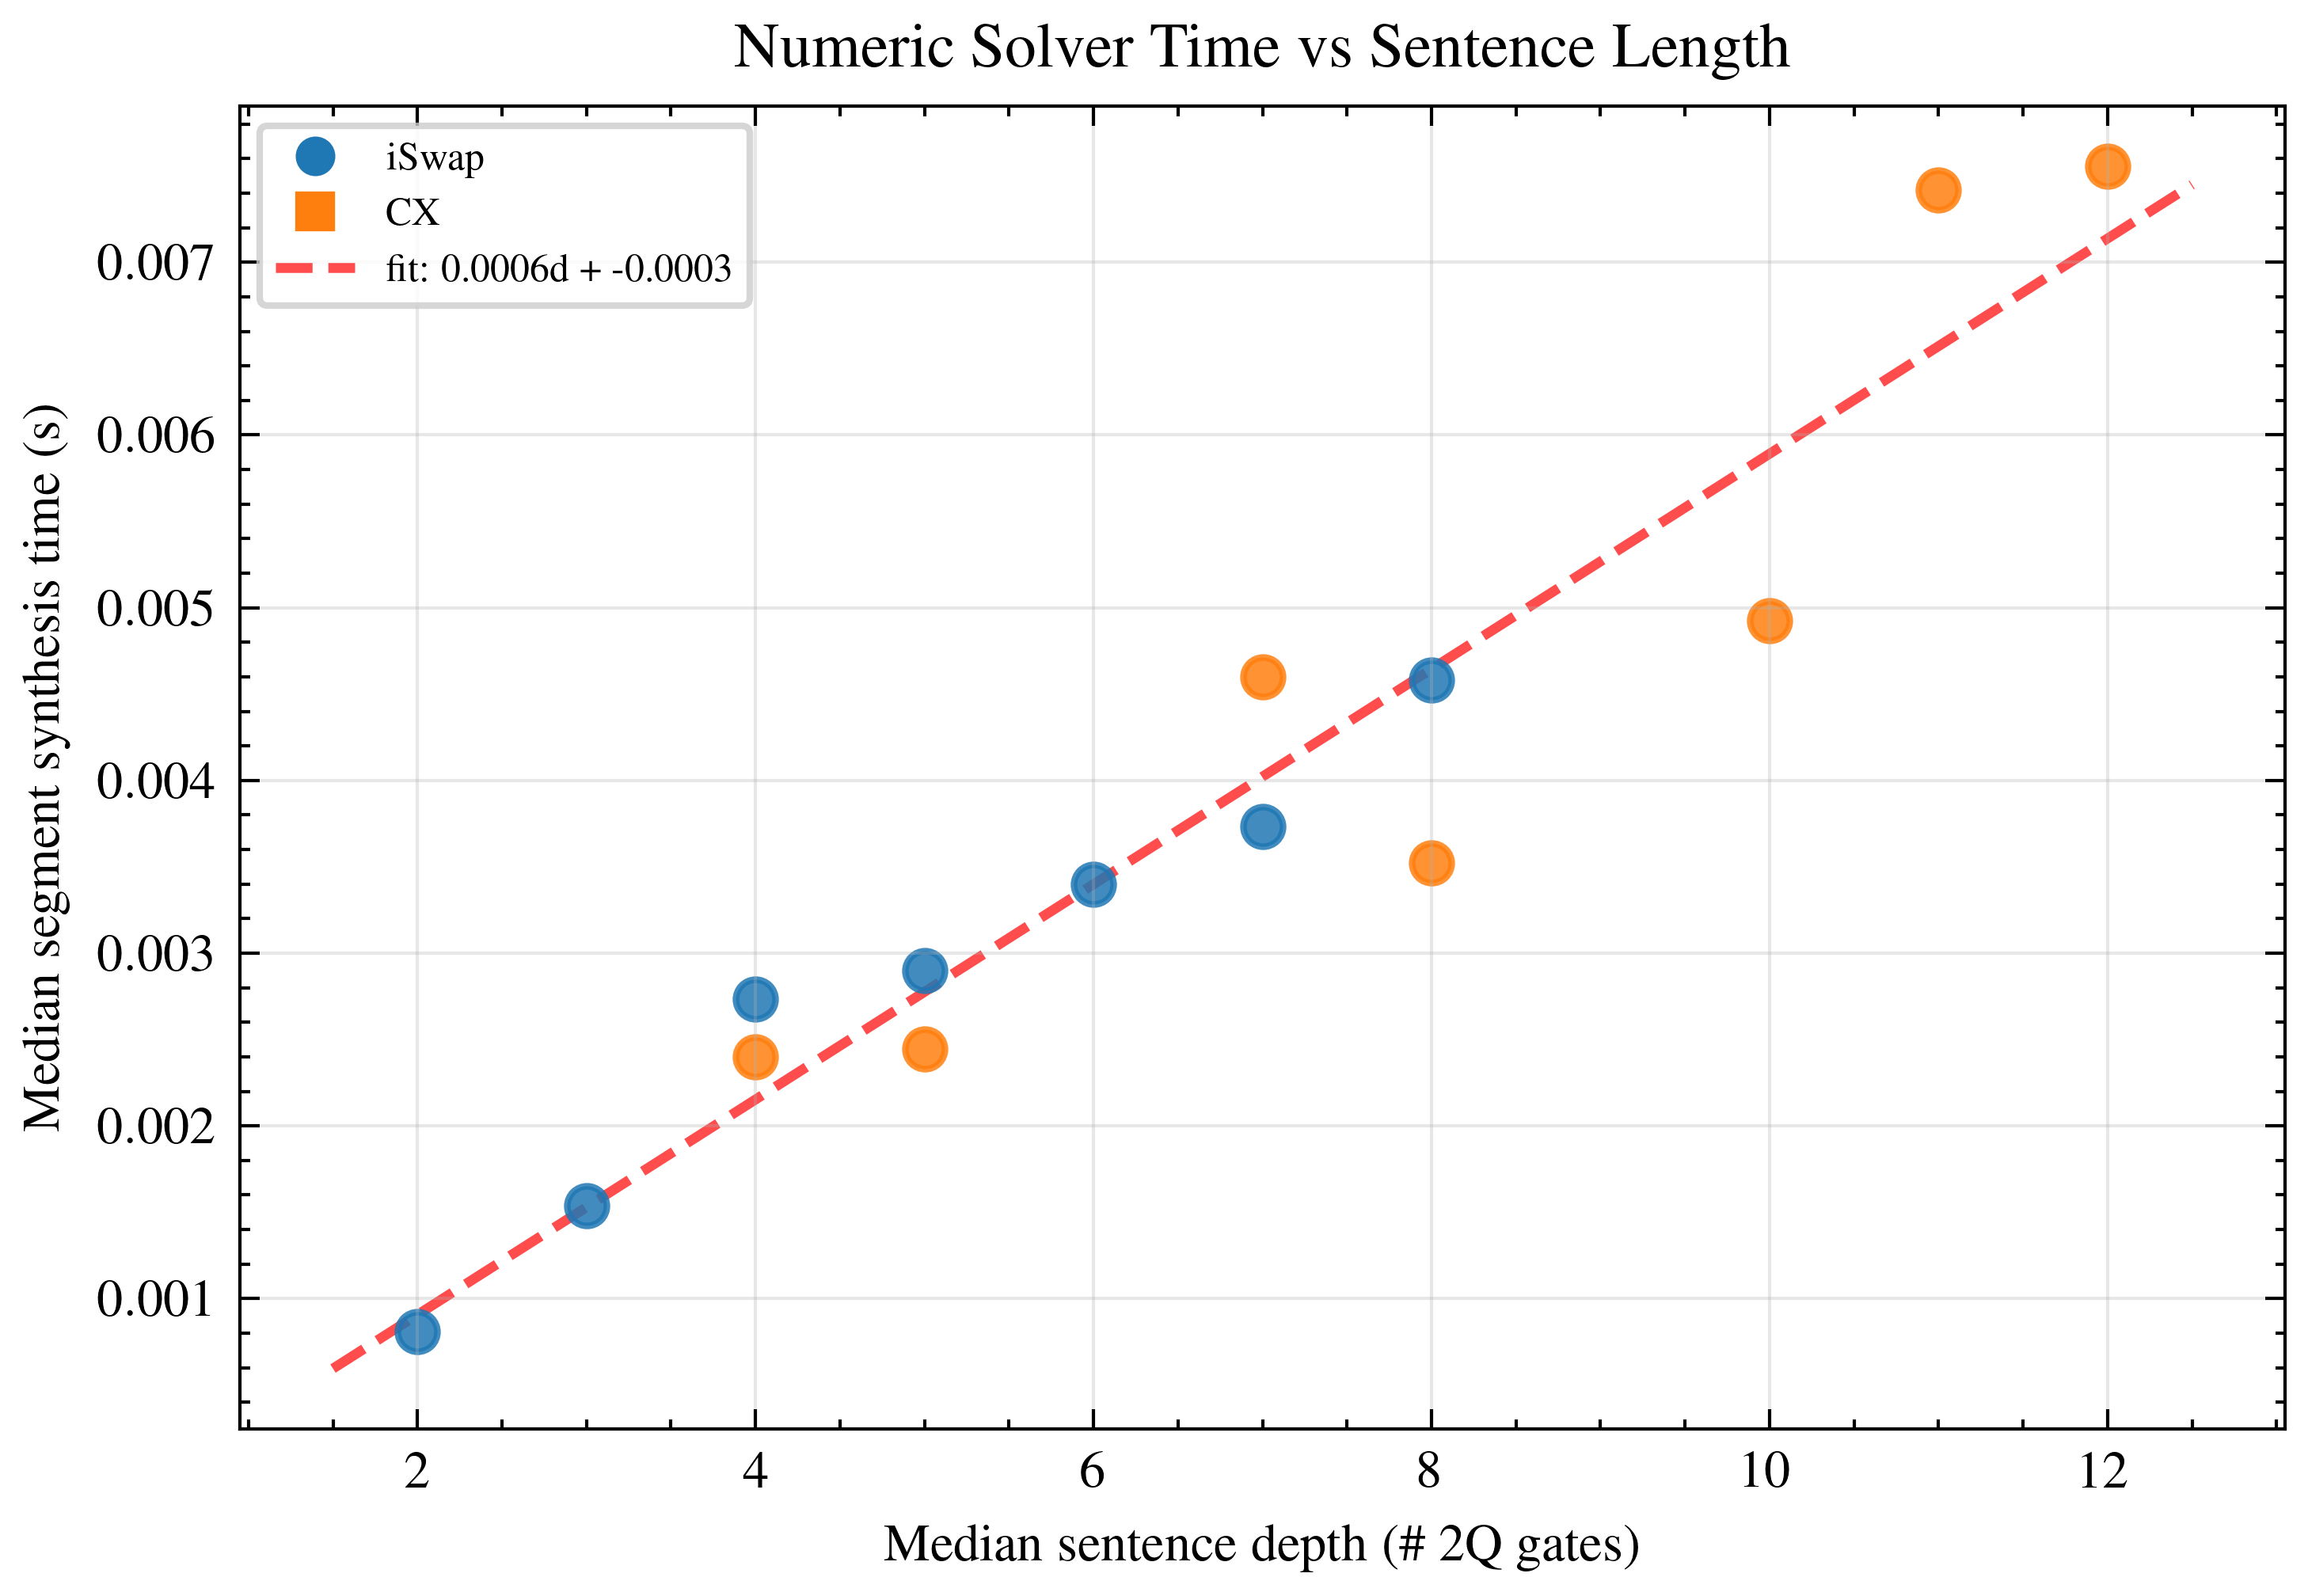

In [7]:
# --- Plot: segment synthesis time vs median sentence depth, colored by gate family ---
gate_families = {
    "iswap": {"color": "tab:blue", "marker": "o", "label": "iSwap"},
    "cx": {"color": "tab:orange", "marker": "s", "label": "CX"},
}


def gate_family_of(name):
    if name.startswith("iswap"):
        return "iswap"
    if name.startswith("cx"):
        return "cx"
    return None


with plt.style.context(["ieee", "science", "use_mathtext"]):
    fig, ax = plt.subplots(figsize=(5, 3.5))

    for r in depth_results:
        if np.isnan(r["median_depth"]):
            continue
        fam = gate_family_of(r["name"])
        sty = gate_families[fam]
        ax.scatter(
            r["median_depth"],
            r["median_seg_time"],
            # yerr=r["std_seg_time"],
            # fmt=sty["marker"],
            color=sty["color"],
            # markersize=5,
            # capsize=3,
            # elinewidth=0.8,
            alpha=0.85,
        )
        # ax.annotate(
        #     r["name"],
        #     (r["median_depth"], r["median_seg_time"]),
        #     fontsize=4.5,
        #     ha="left",
        #     va="bottom",
        #     xytext=(3, 2),
        #     textcoords="offset points",
        #     color=sty["color"],
        # )

    # legend
    for key, sty in gate_families.items():
        ax.plot(
            [], [], sty["marker"], color=sty["color"], label=sty["label"], markersize=5
        )

    # linear fit across all points
    all_x = np.array(
        [r["median_depth"] for r in depth_results if not np.isnan(r["median_depth"])]
    )
    all_y = np.array(
        [
            r["median_seg_time"]
            for r in depth_results
            if not np.isnan(r["median_seg_time"])
        ]
    )
    if len(all_x) > 1:
        coeffs = np.polyfit(all_x, all_y, 1)
        x_fit = np.linspace(all_x.min() - 0.5, all_x.max() + 0.5, 100)
        ax.plot(
            x_fit,
            np.polyval(coeffs, x_fit),
            "--",
            color="red",
            linewidth=1.5,
            label=f"fit: {coeffs[0]:.4f}d + {coeffs[1]:.4f}",
            alpha=0.7,
            zorder=0,
        )

    ax.set_xlabel("Median sentence depth (\\# 2Q gates)")
    ax.set_ylabel("Median segment synthesis time (s)")
    ax.set_title("Numeric Solver Time vs Sentence Length")
    ax.legend(fontsize=6, frameon=True, loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()